<a href="https://colab.research.google.com/github/sanodyaJinadasa/Data-Mining/blob/main/Association_Rule.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
import warnings
import datetime

warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client', message='datetime.datetime.utcnow\(\) is deprecated')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [10]:
transactions=[
    ['Bread','Milk','Butter'],
    ['Bread','Butter'],
    ['Milk','Eggs'],
    ['Bread','Milk','Diaper'],
    ['Milk','Diaper','Beer'],
    ['Bread','Milk','Butter'],
    ['Butter','Diaper'],
    ['Bread','Beer'],
    ['Bread','Milk','Eggs'],
    ['Bread','Milk','Butter']
]

In [11]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

In [12]:
df

,Beer,Bread,Butter,Diaper,Eggs,Milk
0,False,True,True,False,False,True
1,False,True,True,False,False,False
2,False,False,False,False,True,True
3,False,True,False,True,False,True
4,True,False,False,True,False,True
5,False,True,True,False,False,True
6,False,False,True,True,False,False
7,True,True,False,False,False,False
8,False,True,False,False,True,True
9,False,True,True,False,False,True


In [14]:
frequent_itemsets = apriori(df, min_support=0.2, use_colnames=True)
print("Total Frequent Itemsets:", frequent_itemsets.shape[0])

Total Frequent Itemsets: 12


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [18]:
display(frequent_itemsets)

,support,itemsets
0,0.2,(Beer)
1,0.7,(Bread)
2,0.5,(Butter)
3,0.3,(Diaper)
4,0.2,(Eggs)
5,0.7,(Milk)
6,0.4,"(Butter, Bread)"
7,0.5,"(Milk, Bread)"
8,0.3,"(Milk, Butter)"
9,0.2,"(Milk, Diaper)"


In [19]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

print(rules[['antecedents', 'consequents', 'support', 'confidence','lift']])

        antecedents    consequents  support  confidence      lift
0          (Butter)        (Bread)      0.4    0.800000  1.142857
1           (Bread)       (Butter)      0.4    0.571429  1.142857
2            (Milk)        (Bread)      0.5    0.714286  1.020408
3           (Bread)         (Milk)      0.5    0.714286  1.020408
4          (Butter)         (Milk)      0.3    0.600000  0.857143
5          (Diaper)         (Milk)      0.2    0.666667  0.952381
6            (Eggs)         (Milk)      0.2    1.000000  1.428571
7    (Milk, Butter)        (Bread)      0.3    1.000000  1.428571
8     (Milk, Bread)       (Butter)      0.3    0.600000  1.200000
9   (Butter, Bread)         (Milk)      0.3    0.750000  1.071429
10         (Butter)  (Milk, Bread)      0.3    0.600000  1.200000


A strong rule is typically characterized by high confidence and a lift significantly greater than 1. Looking at the table, the rule (Eggs) -> (Milk) stands out with:

Confidence: 1.000000 (100% of the time, if Eggs are bought, Milk is also bought)
Lift: 1.428571 (Customers who buy Eggs are 1.43 times more likely to buy Milk than average)




Customers who purchase eggs are always also buying milk, indicating a very strong co-purchase pattern for breakfast or baking ingredients.

Stores can create combo promotions:
Bread + Butter
Bread + Milk
Breakfast bundles (Eggs + Milk + Bread)
Product placement strategies:
Place butter near bread.
Place milk close to breakfast items.
Recommendation systems in online grocery apps can suggest:
“Customers who bought butter also bought bread.”

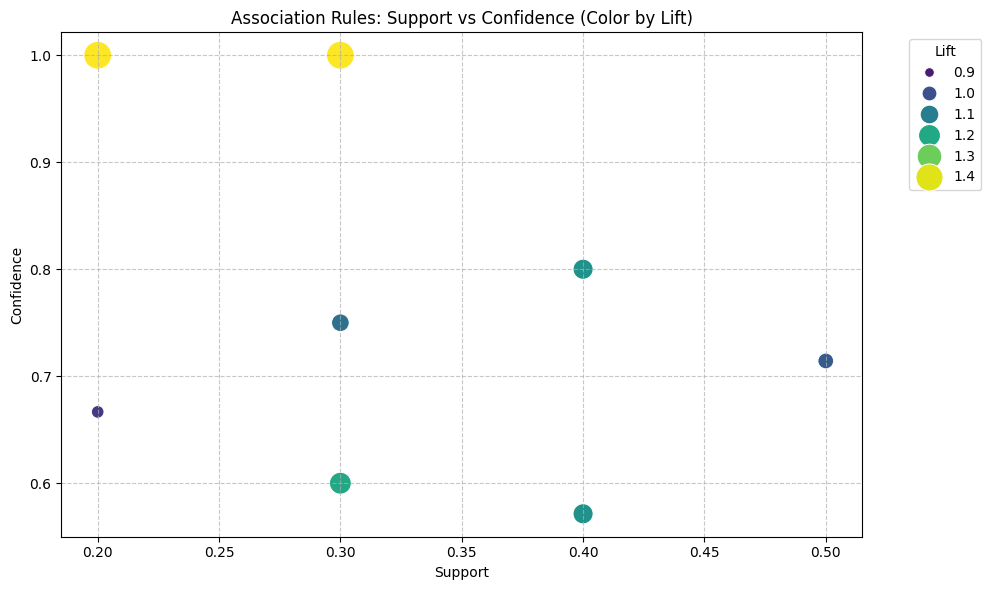

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", data=rules, palette="viridis", sizes=(20, 400))
plt.title('Association Rules: Support vs Confidence (Color by Lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Lift', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()